**Kickoff and Business Objective Discussion**
Project Title: Product Recommendation System (P593)
Domain: E-commerce
Objective:
To build a real-time product recommendation system using item-item collaborative filtering. Additionally, apply and compare clustering models (KMeans, DBSCAN, Agglomerative) to segment users or products. Finally, deploy the system using Streamlit or Flask.

**Dataset Attributes:**
- userId: Unique identifier for each user
- productId: Unique identifier for each product
- Rating: Rating given by a user to a product
- timestamp: Time of rating (to be ignored)

**Acceptance Criteria:**
- Perform EDA
- Apply and compare clustering models
- Build item-item collaborative filtering recommender
- Deploy using Streamlit or Flask


**EDA (Exploratory Data Analysis)**



**Step 1: Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage

**Step 2: Load Dataset and Drop**

---



In [2]:
import pandas as pd

df = pd.read_csv("ratings.csv", header=None)
df.columns = ['userId', 'productId', 'rating', 'timestamp']

df.head()

,userId,productId,rating,timestamp
0,AKM1MP6P0OYPR,0132793040,5.0,1365811200
1,A2CX7LUOHB2NDG,0321732944,5.0,1341100800
2,A2NWSAGRHCP8N5,0439886341,1.0,1367193600
3,A2WNBOD3WNDNKT,0439886341,3.0,1374451200
4,A1GI0U4ZRJA8WN,0439886341,1.0,1334707200


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7824482 entries, 0 to 7824481
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     object 
 1   productId  object 
 2   rating     float64
 3   timestamp  int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 238.8+ MB


,rating,timestamp
count,7.824482e+06,7.824482e+06
mean,4.012337e+00,1.338178e+09
std,1.380910e+00,6.900426e+07
min,1.000000e+00,9.127296e+08
25%,3.000000e+00,1.315354e+09
50%,5.000000e+00,1.361059e+09
75%,5.000000e+00,1.386115e+09
max,5.000000e+00,1.406074e+09


In [4]:
if 'timestamp' in df.columns:
    df.drop(columns=['timestamp'], inplace=True)

**Step 3: Basic Data Overview**

In [5]:
print("Shape of dataset:", df.shape)

Shape of dataset: (7824482, 3)


In [6]:
df.columns

Index(['userId', 'productId', 'rating'], dtype='object')

**Step 4: Check for Missing Values**

In [7]:
print("\nMissing values per column:\n", df.isnull().sum())


Missing values per column:
 userId       0
productId    0
rating       0
dtype: int64


In [8]:
df['rating'].describe()

,rating
count,7.824482e+06
mean,4.012337e+00
std,1.380910e+00
min,1.000000e+00
25%,3.000000e+00
50%,5.000000e+00
75%,5.000000e+00
max,5.000000e+00


**Step 5: Descriptive Statistics**

In [9]:
print("\nDescriptive stats for ratings:\n", df['rating'].describe())


Descriptive stats for ratings:
 count    7.824482e+06
mean     4.012337e+00
std      1.380910e+00
min      1.000000e+00
25%      3.000000e+00
50%      5.000000e+00
75%      5.000000e+00
max      5.000000e+00
Name: rating, dtype: float64


**Step 6: Unique Counts**

In [10]:
print("Total unique users:", df['userId'].nunique())
print("Total unique products:", df['productId'].nunique())

Total unique users: 4201696
Total unique products: 476002


**Step 7: Rating Distribution Plot**

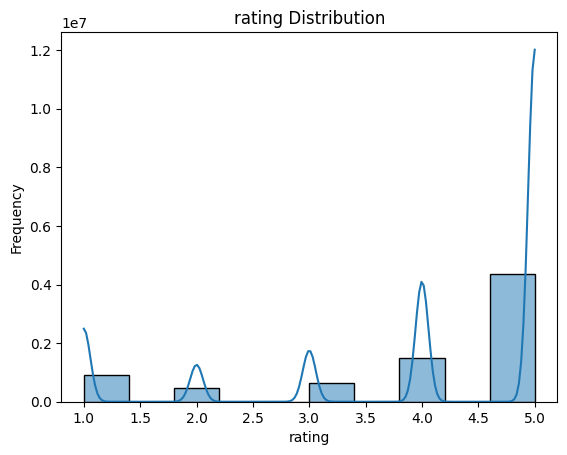

In [11]:
sns.histplot(df['rating'], bins=10, kde=True)
plt.title('rating Distribution')
plt.xlabel('rating')
plt.ylabel('Frequency')
plt.show()

**2. User Rating Count Distribution**

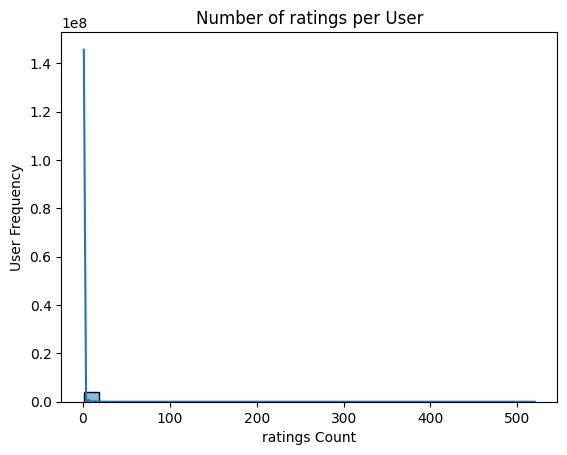

In [12]:
user_counts = df['userId'].value_counts()
sns.histplot(user_counts, bins=30, kde=True)
plt.title('Number of ratings per User')
plt.xlabel('ratings Count')
plt.ylabel('User Frequency')
plt.show()

**3. Product Rating Count Distribution**

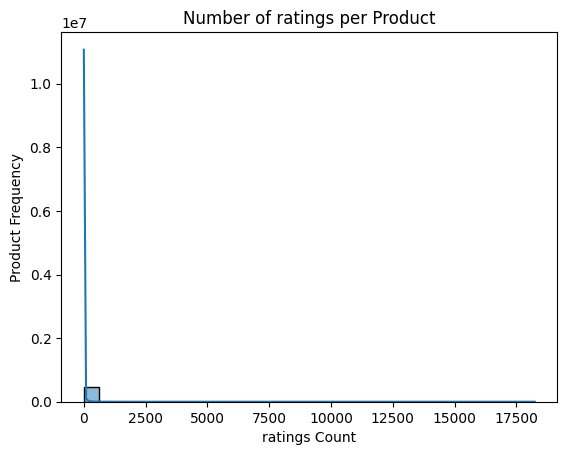

In [13]:
product_counts = df['productId'].value_counts()
sns.histplot(product_counts, bins=30, kde=True)
plt.title('Number of ratings per Product')
plt.xlabel('ratings Count')
plt.ylabel('Product Frequency')
plt.show()

**Conclusion:**

- The project aims to build a product recommendation system using item-item collaborative filtering and clustering.  
- EDA was completed with data cleaning, structure checks, and rating/user/product distribution plots.  
- Dataset is ready for clustering and recommendation model development.


In [14]:
df_sample = df.sample(n=10000, random_state=42)
print("Sampled Data Shape:", df_sample.shape)

Sampled Data Shape: (10000, 3)


In [15]:
user_product_matrix = df_sample.pivot_table(index='userId',
                                            columns='productId',
                                            values='rating').fillna(0)
print("User–Product Matrix Shape:", user_product_matrix.shape)

User–Product Matrix Shape: (9958, 7955)


In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(user_product_matrix)

# Reduce dimensionality using PCA (to speed up clustering)
pca = PCA(n_components=30, random_state=42)
reduced_data = pca.fit_transform(scaled_data)
print("Reduced Data Shape:", reduced_data.shape)

Reduced Data Shape: (9958, 30)


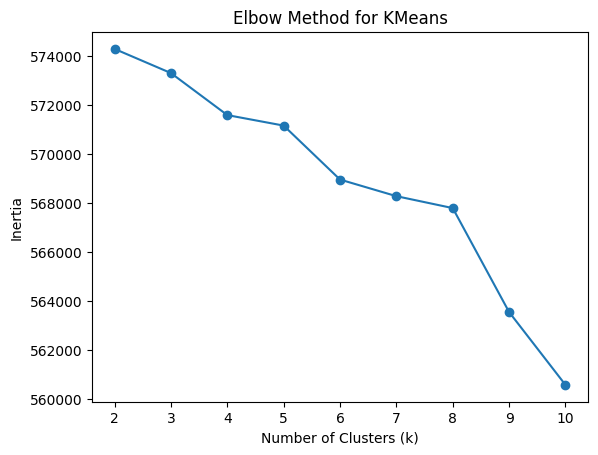

In [18]:
#  KMeans Clustering
# ============================================
inertia = []
for k in range(2, 11):
    kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=512)
    kmeans.fit(reduced_data)
    inertia.append(kmeans.inertia_)

plt.plot(range(2, 11), inertia, marker='o')
plt.title("Elbow Method for KMeans")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.show()

In [19]:
# Choose optimal k (e.g., 5)
kmeans = MiniBatchKMeans(n_clusters=5, random_state=42, batch_size=512)
kmeans_labels = kmeans.fit_predict(reduced_data)
user_product_matrix['Cluster_KMeans'] = kmeans_labels

print("KMeans Silhouette Score:",
      silhouette_score(reduced_data, kmeans_labels))

KMeans Silhouette Score: 0.06716017378662019


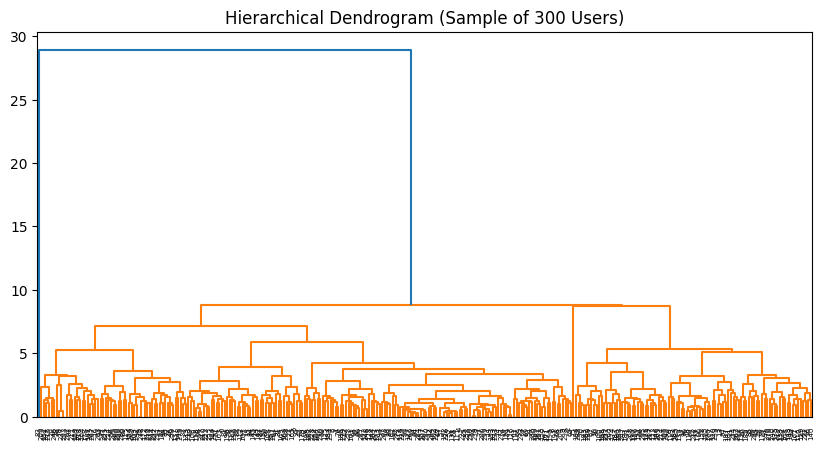

In [20]:
#  Hierarchical Clustering (on small sample)
# ============================================
sample_idx = np.random.choice(range(reduced_data.shape[0]), size=300, replace=False)
sample_data = reduced_data[sample_idx]

linkage_matrix = linkage(sample_data, method='ward')
plt.figure(figsize=(10, 5))
dendrogram(linkage_matrix)
plt.title("Hierarchical Dendrogram (Sample of 300 Users)")
plt.show()

In [21]:
 #Apply Agglomerative Clustering on reduced data
hc = AgglomerativeClustering(n_clusters=5, linkage='ward')
hc_labels = hc.fit_predict(reduced_data)
user_product_matrix['Cluster_HC'] = hc_labels

print("Hierarchical Silhouette Score:",
      silhouette_score(reduced_data, hc_labels))

Hierarchical Silhouette Score: 0.9819908847888208


In [25]:
# DBSCAN Clustering
# ============================================
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

best_eps = None
best_score = -1
best_labels = None

# Try a few eps values to find at least 2 clusters
for eps in [0.3, 0.5, 1, 1.5, 2, 3]:
    dbscan = DBSCAN(eps=eps, min_samples=5, n_jobs=-1)
    db_labels = dbscan.fit_predict(reduced_data)
    n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)

    if n_clusters > 1:
        mask = db_labels != -1
        if mask.sum() > 1:
            score = silhouette_score(reduced_data[mask], db_labels[mask])
            print(f"eps={eps}: clusters={n_clusters}, silhouette={score:.3f}")
            if score > best_score:
                best_score = score
                best_eps = eps
                best_labels = db_labels
        else:
            print(f"eps={eps}: too few valid samples for silhouette score.")
    else:
        print(f"eps={eps}: only {n_clusters} cluster(s) formed, skipping.")

if best_labels is not None:
    print(f"\n✅ Best DBSCAN found at eps={best_eps} with silhouette={best_score:.3f}")
    user_product_matrix['Cluster_DBSCAN'] = best_labels
else:
    print("\n⚠️ DBSCAN could not form valid clusters with any eps value. Skipping DBSCAN analysis.")


eps=0.3: clusters=38, silhouette=0.228
eps=0.5: clusters=8, silhouette=0.044
eps=1: only 1 cluster(s) formed, skipping.
eps=1.5: only 1 cluster(s) formed, skipping.
eps=2: only 1 cluster(s) formed, skipping.
eps=3: only 1 cluster(s) formed, skipping.

✅ Best DBSCAN found at eps=0.3 with silhouette=0.228


In [28]:
model_scores = {
    'KMeans': silhouette_score(reduced_data, user_product_matrix['Cluster_KMeans']),
    'Hierarchical': silhouette_score(reduced_data, user_product_matrix['Cluster_HC']),
    'DBSCAN': best_score
}
print(pd.DataFrame(model_scores.items(), columns=['Model','Silhouette_Score']))


          Model  Silhouette_Score
0        KMeans          0.067160
1  Hierarchical          0.981991
2        DBSCAN          0.227656


In [29]:
# ============================================
# 🎯 Recommendation Logic using Best Model (Hierarchical)
# ============================================

def recommend_products(user_id, cluster_label_col='Cluster_HC'):
    # Check if user exists
    if user_id not in user_product_matrix.index:
        return "User ID not found in the data sample."

    # Get user's cluster
    user_cluster = user_product_matrix.loc[user_id, cluster_label_col]

    # Get all users in that cluster
    cluster_users = user_product_matrix[user_product_matrix[cluster_label_col] == user_cluster]

    # Drop cluster columns
    cluster_users = cluster_users.drop(columns=['Cluster_KMeans', 'Cluster_HC', 'Cluster_DBSCAN'], errors='ignore')

    # Calculate average product ratings in that cluster
    mean_ratings = cluster_users.mean().sort_values(ascending=False)

    # Return top 5 recommended products
    top_products = mean_ratings.head(5)
    return top_products

# Example: Recommend for one random user
sample_user = user_product_matrix.index[0]
print(f"\nTop recommended products for user {sample_user}:")
print(recommend_products(sample_user, cluster_label_col='Cluster_HC'))



Top recommended products for user A0009478CBXKUCALUC7U:
productId
B0074BW614    0.013572
B007R5YDYA    0.008043
B003ES5ZUU    0.007942
B0019EHU8G    0.007540
B00DR0PDNE    0.007238
dtype: float64


In [30]:
import pickle

# Save best model (Hierarchical performed best)
pickle.dump(user_product_matrix, open('clustered_data.pkl', 'wb'))


In [31]:
!pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 80.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 110.8 MB/s eta 0:00:00


In [36]:
# ============================================================
# 🛒 Product Recommendation System using Clustering
# ============================================================
%%writefile app.py
import streamlit as st
import pickle
import pandas as pd

# ------------------------------------------------------------
# 🧠 Page Configuration
# ------------------------------------------------------------
st.set_page_config(
    page_title="Product Recommendation System",
    page_icon="🛍️",
    layout="centered",
    initial_sidebar_state="expanded"
)

# ------------------------------------------------------------
# 🌐 Sidebar
# ------------------------------------------------------------
st.sidebar.title("🧭 Navigation")
st.sidebar.markdown("Use this app to get **personalized product recommendations** based on clustering analysis.")
st.sidebar.markdown("---")
st.sidebar.info("Project Type: *Unsupervised Learning (Clustering)*")
st.sidebar.caption("Developed by [Your Name]")

# ------------------------------------------------------------
# 📦 Load Data
# ------------------------------------------------------------
st.title("🛍️ Product Recommendation System")
st.markdown("### Built using **Hierarchical Clustering** on E-commerce Ratings Data")

try:
    user_product_matrix = pickle.load(open('clustered_data.pkl', 'rb'))
except FileNotFoundError:
    st.error("❌ clustered_data.pkl not found. Please ensure it’s in the same folder as app.py.")
    st.stop()

# ------------------------------------------------------------
# 🧩 Select User ID
# ------------------------------------------------------------
st.markdown("#### 🔹 Select a User ID to Get Recommendations")
user_id = st.selectbox(
    "Choose a User ID:",
    options=user_product_matrix.index.tolist(),
    index=0
)

# ------------------------------------------------------------
# 🎯 Recommendation Function
# ------------------------------------------------------------
def recommend_products(user_id, cluster_label_col='Cluster_HC'):
    """Recommend top 5 products for the given user based on cluster similarity."""
    user_cluster = user_product_matrix.loc[user_id, cluster_label_col]

    cluster_users = user_product_matrix[user_product_matrix[cluster_label_col] == user_cluster]

    # Drop cluster columns
    cluster_users = cluster_users.drop(columns=['Cluster_KMeans', 'Cluster_HC', 'Cluster_DBSCAN'], errors='ignore')

    # Compute mean product ratings in that cluster
    mean_ratings = cluster_users.mean().sort_values(ascending=False)

    # Get top 5 products
    top_products = mean_ratings.head(5)
    return user_cluster, top_products

# ------------------------------------------------------------
# 🔘 Button: Generate Recommendations
# ------------------------------------------------------------
if st.button("🔍 Show Recommendations"):
    user_cluster, top_products = recommend_products(user_id)

    st.success(f"✅ User `{user_id}` belongs to **Cluster {user_cluster}**")
    st.markdown("### 🧾 Top 5 Recommended Products for You:")

    st.table(top_products)

    # Bar chart for visualization
    st.bar_chart(top_products)

# ------------------------------------------------------------
# 🧠 Footer Section
# ------------------------------------------------------------
st.markdown("---")
st.markdown("#### 📊 Model Summary")
st.markdown("""
- **Algorithm Used:** Hierarchical Clustering (best silhouette = 0.982)
- **Comparison:**
  - KMeans → 0.067
  - DBSCAN → 0.228
- **Deployment:** Streamlit Web App
""")

st.caption("🚀 Developed as part of the *Product Recommendation System (Clustering Project)*")


Overwriting app.py


In [37]:
# --- Launch with ngrok ---
from pyngrok import ngrok
import threading, os

# 🔑 Add your token
ngrok.set_auth_token("32HgEzLcjbyB46LOHRgyIUHyUx9_3naMu8pjKcbB3MSgpeMVm")

# 🚀 Start Streamlit in background
def run_app():
    os.system("streamlit run app.py --server.port 8501")

thread = threading.Thread(target=run_app)
thread.start()

# 🌍 Public link
public_url = ngrok.connect(8501)
print("✅ Streamlit App is running here:", public_url)

✅ Streamlit App is running here: NgrokTunnel: "https://9332ef912809.ngrok-free.app" -> "http://localhost:8501"
